In [10]:

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

PROCESSED_DIR = "../data/processed/"

train_df = pd.read_csv(PROCESSED_DIR + "train_clean.csv")
test_df  = pd.read_csv(PROCESSED_DIR + "test_clean.csv")

y_train = train_df["Survived"].copy()
X_train = train_df.drop(columns=["Survived"])
X_test  = test_df.copy()


X_test["Fare"] = X_test["Fare"].fillna(X_train["Fare"].median())

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("Missing values — train:", X_train.isnull().sum().sum())
print("Missing values — test :", X_test.isnull().sum().sum())

X_train shape: (891, 11)
X_test shape : (418, 11)
y_train shape: (891,)
Missing values — train: 0
Missing values — test : 0


In [12]:

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

numeric_features = [
    "Pclass", "Age", "SibSp", "Parch", "Fare",
    "FamilySize", "IsAlone", "HasCabin"
]

categorical_features = [
    "Sex", "Embarked", "Title"
]

print("X_tr shape :", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr shape :", y_tr.shape)
print("y_val shape:", y_val.shape)

print("\nNumeric features    :", numeric_features)
print("Categorical features:", categorical_features)

X_tr shape : (712, 11)
X_val shape: (179, 11)
y_tr shape : (712,)
y_val shape: (179,)

Numeric features    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']
Categorical features: ['Sex', 'Embarked', 'Title']


In [13]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print(" Preprocessor ready")
print(" Models imported:")
print("   - LogisticRegression")
print("   - DecisionTreeClassifier")
print("   - RandomForestClassifier")

 Preprocessor ready
 Models imported:
   - LogisticRegression
   - DecisionTreeClassifier
   - RandomForestClassifier


In [16]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

def train_and_evaluate(name, model, X_tr, y_tr, X_val, y_val):
    """
    Build a pipeline (preprocessor + model), fit on train, evaluate on val.
    Returns a dict of metrics for later comparison.
    """
    # 1. Wrap preprocessor + model in a pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    
    pipe.fit(X_tr, y_tr)

    
    y_pred = pipe.predict(X_val)


    metrics = {
        "model":     name,
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "f1":        f1_score(y_val, y_pred),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")
    print(f"  F1       : {metrics['f1']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print(f"\n  Classification Report:")
    print(classification_report(y_val, y_pred, target_names=["Died", "Survived"]))

    return metrics

In [18]:

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_metrics = train_and_evaluate(
    "Logistic Regression",
    lr_model,
    X_tr, y_tr,
    X_val, y_val
)


  Logistic Regression
  Accuracy : 0.8436
  Precision: 0.8060
  Recall   : 0.7826
  F1       : 0.7941

  Confusion Matrix:
[[97 13]
 [15 54]]

  Classification Report:
              precision    recall  f1-score   support

        Died       0.87      0.88      0.87       110
    Survived       0.81      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [20]:

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_metrics = train_and_evaluate(
    "Decision Tree",
    dt_model,
    X_tr, y_tr,
    X_val, y_val
)


  Decision Tree
  Accuracy : 0.7877
  Precision: 0.8039
  Recall   : 0.5942
  F1       : 0.6833

  Confusion Matrix:
[[100  10]
 [ 28  41]]

  Classification Report:
              precision    recall  f1-score   support

        Died       0.78      0.91      0.84       110
    Survived       0.80      0.59      0.68        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179



In [21]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_metrics = train_and_evaluate(
    "Random Forest",
    rf_model,
    X_tr, y_tr,
    X_val, y_val
)


  Random Forest
  Accuracy : 0.8212
  Precision: 0.7846
  Recall   : 0.7391
  F1       : 0.7612

  Confusion Matrix:
[[96 14]
 [18 51]]

  Classification Report:
              precision    recall  f1-score   support

        Died       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



=== Model Comparison (sorted by accuracy) ===
                     accuracy  precision  recall      f1
model                                                   
Logistic Regression    0.8436     0.8060  0.7826  0.7941
Random Forest          0.8212     0.7846  0.7391  0.7612
Decision Tree          0.7877     0.8039  0.5942  0.6833


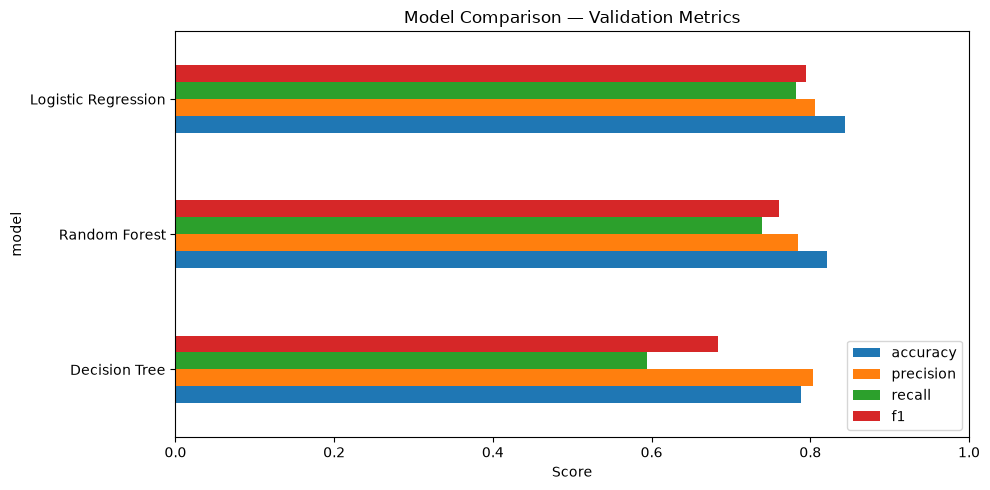

In [23]:

results = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics])
results = results.set_index("model").round(4)

print("=== Model Comparison (sorted by accuracy) ===")
print(results.sort_values("accuracy", ascending=False))


import matplotlib.pyplot as plt
results_sorted = results.sort_values("accuracy")
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

results_sorted[metrics_to_plot].plot(kind="barh", figsize=(10, 5))
plt.title("Model Comparison — Validation Metrics")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [24]:

from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
}

print("=== 5-Fold Cross-Validation (Full Training Set) ===\n")

cv_results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name}")
    print(f"  Fold scores : {scores.round(4)}")
    print(f"  Mean        : {scores.mean():.4f}")
    print(f"  Std         : {scores.std():.4f}\n")

=== 5-Fold Cross-Validation (Full Training Set) ===

Logistic Regression
  Fold scores : [0.8268 0.809  0.7978 0.8202 0.8764]
  Mean        : 0.8260
  Std         : 0.0271

Decision Tree
  Fold scores : [0.7989 0.7865 0.8371 0.764  0.8427]
  Mean        : 0.8058
  Std         : 0.0300

Random Forest
  Fold scores : [0.8547 0.8202 0.8258 0.8034 0.8652]
  Mean        : 0.8339
  Std         : 0.0228

